<a href="https://colab.research.google.com/github/sapienology/deep-learning-projects/blob/main/DIABETES_(DEEP_LEARNING).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

## **EDA**

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df["diabetes"].value_counts()

,count
diabetes,
0,91500
1,8500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## Check for unique values

In [ ]:
df["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
df["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

## Change Datatype

In [ ]:
df['gender'] = df['gender'].replace({'Female': 0, 'Male': 1, 'Other': 2})


/tmp/ipykernel_14554/1753590414.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Female': 0, 'Male': 1, 'Other': 2})


In [ ]:
df['smoking_history'] = df['smoking_history'].replace({'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5})


/tmp/ipykernel_14554/3202853213.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoking_history'] = df['smoking_history'].replace({'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5})


In [ ]:
df['age'] = df['age'].astype(int)

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80,0,1,0,25.19,6.6,140,0
1,0,54,0,0,1,27.32,6.6,80,0
2,1,28,0,0,0,27.32,5.7,158,0
3,0,36,0,0,2,23.45,5.0,155,0
4,1,76,1,1,2,20.14,4.8,155,0


## Split data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns = ['diabetes'])

In [ ]:
y = df['diabetes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
75220,1,73,0,0,3,24.77,3.5,80
48955,1,80,0,0,0,24.60,5.7,145
44966,0,38,0,0,4,24.33,4.0,158
13568,0,26,0,0,5,18.87,5.0,100
92727,0,61,1,0,2,22.11,4.5,85
...,...,...,...,...,...,...,...,...
6265,1,49,0,0,0,32.98,5.7,80
54886,0,15,0,0,0,28.10,5.0,159
76820,1,42,0,0,0,26.14,5.8,85
860,0,37,0,0,0,24.96,6.2,158


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log = LogisticRegression()

In [ ]:
log.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
pred = log.predict(X_test)

In [ ]:
pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test.values

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
new = {"pred": pred, "y_test": y_test}

### **Performance metrics**

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.60      0.70      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.79      0.84     20000
weighted avg       0.95      0.96      0.95     20000



**HyperParameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
log_param = {"C":[0.1,1], "penalty":["l1","l2"]}

In [ ]:
grid = GridSearchCV(
    LogisticRegression(),
    log_param
)

In [ ]:
grid.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1], 'penalty': ['l1', 'l2']})

In [ ]:
grid.best_estimator_

LogisticRegression(C=0.1)

In [ ]:
grid_pred = grid.predict(X_test)

In [ ]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     18292
           1       0.83      0.56      0.67      1708

    accuracy                           0.95     20000
   macro avg       0.89      0.78      0.82     20000
weighted avg       0.95      0.95      0.95     20000



### **Data Normalization**

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=42)

In [ ]:
X_resampled, y_resampled = sm.fit_resample(X,y)

In [ ]:
y_resampled.value_counts()

,count
diabetes,
0,91500
1,91500


In [ ]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
#from sklearn.preprocessing import StandardScaler

In [ ]:
#scaler = StandardScaler()

In [ ]:
scaled_X_train = scaler.fit_transform(X_train_new)

In [ ]:
scaled_X_test = scaler.transform(X_test_new)

In [ ]:
logistic = LogisticRegression()

In [ ]:
logistic.fit(scaled_X_train,y_train_new)

LogisticRegression()

In [ ]:
pred_new = logistic.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test_new,pred_new))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     18293
           1       0.88      0.89      0.89     18307

    accuracy                           0.89     36600
   macro avg       0.89      0.89      0.89     36600
weighted avg       0.89      0.89      0.89     36600



# Using SVM

In [ ]:
from sklearn import svm

In [ ]:
clf = svm.SVC()


In [ ]:
clf.fit(scaled_X_train,y_train_new)

SVC()

In [ ]:
pred_new_svm = clf.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test_new,pred_new_svm))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90     18293
           1       0.89      0.92      0.90     18307

    accuracy                           0.90     36600
   macro avg       0.90      0.90      0.90     36600
weighted avg       0.90      0.90      0.90     36600



# Decision Trees

In [ ]:
from sklearn import tree

In [ ]:
dt_clf = tree.DecisionTreeClassifier()

In [ ]:
dt_clf.fit(scaled_X_train,y_train_new)

DecisionTreeClassifier()

In [ ]:
pred_new_dt = dt_clf.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test_new,pred_new_dt))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18293
           1       0.97      0.98      0.97     18307

    accuracy                           0.97     36600
   macro avg       0.97      0.97      0.97     36600
weighted avg       0.97      0.97      0.97     36600



# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=10)


In [ ]:
rf_clf.fit(scaled_X_train,y_train_new)

RandomForestClassifier(n_estimators=10)

In [ ]:
pred_new_rf = rf_clf.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test_new,pred_new_rf))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     18293
           1       0.97      0.96      0.97     18307

    accuracy                           0.97     36600
   macro avg       0.97      0.97      0.97     36600
weighted avg       0.97      0.97      0.97     36600



# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
gnb = GaussianNB()

In [ ]:
gnb.fit(scaled_X_train,y_train_new)

GaussianNB()

In [ ]:
pred_new_gnb =gnb.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test_new,pred_new_gnb))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85     18293
           1       0.87      0.81      0.84     18307

    accuracy                           0.84     36600
   macro avg       0.84      0.84      0.84     36600
weighted avg       0.84      0.84      0.84     36600



# SGD

In [ ]:
from sklearn.linear_model import SGDClassifier

In [ ]:
sgd_clf = SGDClassifier(loss="hinge", penalty="l2", max_iter=5)

In [ ]:
sgd_clf.fit(scaled_X_train,y_train_new)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDClassifier(max_iter=5)

In [ ]:
pred_new_sgd = sgd_clf.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test_new,pred_new_sgd))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     18293
           1       0.89      0.88      0.88     18307

    accuracy                           0.88     36600
   macro avg       0.88      0.88      0.88     36600
weighted avg       0.88      0.88      0.88     36600



# Model Performance

In [ ]:
#Stochastic Gradient Descent
print(classification_report(y_test_new,pred_new_sgd))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     18293
           1       0.89      0.88      0.88     18307

    accuracy                           0.88     36600
   macro avg       0.88      0.88      0.88     36600
weighted avg       0.88      0.88      0.88     36600



In [ ]:
#Naive Bayes
print(classification_report(y_test_new,pred_new_gnb))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85     18293
           1       0.87      0.81      0.84     18307

    accuracy                           0.84     36600
   macro avg       0.84      0.84      0.84     36600
weighted avg       0.84      0.84      0.84     36600



In [ ]:
#Random Forest
print(classification_report(y_test_new,pred_new_rf))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     18293
           1       0.97      0.96      0.97     18307

    accuracy                           0.97     36600
   macro avg       0.97      0.97      0.97     36600
weighted avg       0.97      0.97      0.97     36600



In [ ]:
#Decision Trees
print(classification_report(y_test_new,pred_new_dt))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18293
           1       0.97      0.98      0.97     18307

    accuracy                           0.97     36600
   macro avg       0.97      0.97      0.97     36600
weighted avg       0.97      0.97      0.97     36600



In [ ]:
#Support Vector Machines
print(classification_report(y_test_new,pred_new_svm))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90     18293
           1       0.89      0.92      0.90     18307

    accuracy                           0.90     36600
   macro avg       0.90      0.90      0.90     36600
weighted avg       0.90      0.90      0.90     36600



In [ ]:
#Logistic Regression
print(classification_report(y_test_new,pred_new))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     18293
           1       0.88      0.89      0.89     18307

    accuracy                           0.89     36600
   macro avg       0.89      0.89      0.89     36600
weighted avg       0.89      0.89      0.89     36600



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    # ── Input ──
    layers.Input(shape=(8,), name="input_layer"),

    # ── Hidden Layer 1 ──
    layers.Dense(16, activation="relu", name="hidden_1"),
    layers.Dropout(0.2, name="dropout_1"),

    # ── Hidden Layer 2 ──
    layers.Dense(8, activation="relu", name="hidden_2"),
    layers.Dropout(0.2, name="dropout_2"),

    # ── Output ──
    layers.Dense(1, activation="sigmoid", name="output_layer"),
], name="student_pass_predictor")

model.summary()


Model: "student_pass_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile: choose optimizer, loss, and metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",   # standard loss for binary classification
    metrics=["accuracy"]
)

print("✅ Model compiled!")
print("\nKey choices:")
print("  Optimizer  : Adam (adaptive learning rate — great default choice)")
print("  Loss       : Binary Crossentropy (for 0/1 output)")
print("  Metric     : Accuracy (% correct predictions)")


✅ Model compiled!

Key choices:
  Optimizer  : Adam (adaptive learning rate — great default choice)
  Loss       : Binary Crossentropy (for 0/1 output)
  Metric     : Accuracy (% correct predictions)


In [ ]:
history = model.fit(
    X_train_new, y_train_new,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

print("\n✅ Training complete!")


Epoch 1/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.7014 - loss: 0.6215 - val_accuracy: 0.7533 - val_loss: 0.4617
Epoch 2/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.8232 - loss: 0.3846 - val_accuracy: 0.7657 - val_loss: 0.4452
Epoch 3/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - accuracy: 0.8509 - loss: 0.3294 - val_accuracy: 0.7746 - val_loss: 0.4282
Epoch 4/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.8582 - loss: 0.3164 - val_accuracy: 0.7787 - val_loss: 0.4019
Epoch 5/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.8614 - loss: 0.3091 - val_accuracy: 0.8111 - val_loss: 0.3420
Epoch 6/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.8635 - loss: 0.3040 - val_accuracy: 0.7273 - val_loss: 0.5545
Epoch 7/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.8650 - loss: 0.3014 - val_accuracy: 0.8078 - val_loss: 0.3588
Epoch 8/10
14640/14640 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - accuracy: 

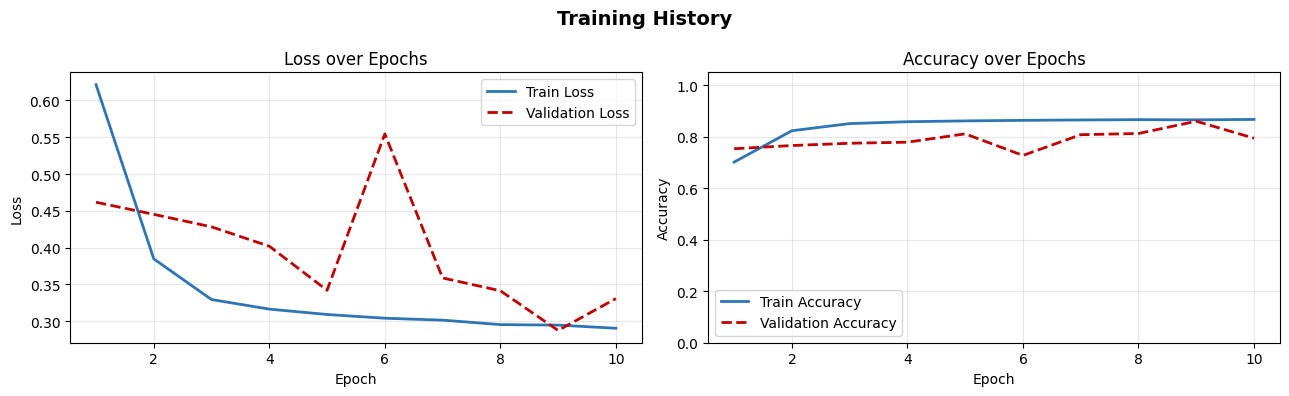

In [ ]:
# ─── Plot training curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

epochs_range = range(1, 11)

# Loss
ax1.plot(epochs_range, history.history["loss"],     color="#2E75B6", label="Train Loss",      linewidth=2)
ax1.plot(epochs_range, history.history["val_loss"],  color="#C00000", label="Validation Loss", linewidth=2, linestyle="--")
ax1.set_title("Loss over Epochs"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history.history["accuracy"],     color="#2E75B6", label="Train Accuracy",      linewidth=2)
ax2.plot(epochs_range, history.history["val_accuracy"],  color="#C00000", label="Validation Accuracy", linewidth=2, linestyle="--")
ax2.set_title("Accuracy over Epochs"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_new, y_test_new, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.1f}%")


Test Loss     : 0.3362
Test Accuracy : 79.2%


=== Classification Report ===
              precision    recall  f1-score   support

        FAIL       0.71      1.00      0.83     18293
        PASS       1.00      0.59      0.74     18307

    accuracy                           0.79     36600
   macro avg       0.85      0.79      0.78     36600
weighted avg       0.85      0.79      0.78     36600



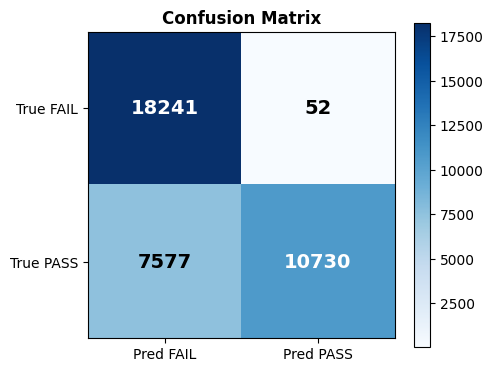


True Positives  (correctly predicted PASS): 10730
True Negatives  (correctly predicted FAIL): 18241
False Positives (predicted PASS, actually FAIL): 52
False Negatives (predicted FAIL, actually PASS): 7577


In [ ]:
# Predictions
y_pred_prob = model.predict(X_test_new, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)   # threshold at 0.5

print("=== Classification Report ===")
print(classification_report(y_test_new, y_pred, target_names=["FAIL", "PASS"]))

# Confusion matrix
cm = confusion_matrix(y_test_new, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred FAIL","Pred PASS"]); ax.set_yticklabels(["True FAIL","True PASS"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax.set_title("Confusion Matrix", fontweight="bold")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nTrue Positives  (correctly predicted PASS):", cm[1,1])
print("True Negatives  (correctly predicted FAIL):", cm[0,0])
print("False Positives (predicted PASS, actually FAIL):", cm[0,1])
print("False Negatives (predicted FAIL, actually PASS):", cm[1,0])